### 定义 `SleepStageNetV8`


In [1]:
import torch
import torch.nn as nn

# --- 模型（n通道输入）---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch) # 新增注意力
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out) # 赋予特征通道权重
        return self.elu(out + self.shortcut(x))

# --- 修改后的主网络 ---
class SleepStageNetV8(nn.Module):
    def __init__(self, num_classes, window_size=15):
        super().__init__()
        self.window_size = window_size
        self.n_fft = 512
        self.hop_length = 64
        
        # --- 分支 A: 频谱特征提取 (2D CNN) ---
        self.spec_stem = nn.Sequential(
            nn.Conv2d(1, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        self.spec_stage = nn.Sequential(
            ResBlock(32, 64, stride=2),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128, stride=2), # 缩减输出通道为128
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # --- 分支 B: 原始波形特征提取 (1D CNN) ---
        # 模仿 TinySleepNet/DeepSleepNet 的小核+大核思想简化版
        self.raw_branch = nn.Sequential(
            # 第一层使用较大的卷积核捕捉低频节律 (如 Delta 波)
            nn.Conv1d(1, 64, kernel_size=64, stride=8, padding=32, bias=False),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=8, stride=8),
            # 第二层捕捉局部细节
            nn.Conv1d(64, 128, kernel_size=16, stride=1, padding=8, bias=False),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(1) # 输出维度 (B*T, 128, 1)
        )
        
        # --- 融合与时序层 ---
        # 两个分支各出 128 维，合起来是 256
        self.rnn = nn.GRU(128 + 128, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [Batch, n, 1, 3001]
        b, t, c, s = x.shape
        x_flat = x.view(b * t, c, s) # [B*T, 1, 3001]
        
        # --- 1. 频谱分支 (2D) ---
        # 在 forward 内部计算频谱
        win = torch.hann_window(self.n_fft).to(x.device)
        stft = torch.stft(x_flat.squeeze(1), n_fft=self.n_fft, hop_length=self.hop_length, 
                          window=win, return_complex=True, center=True)
        mag = (torch.abs(stft) + 1e-8).log().unsqueeze(1) # [B*T, 1, F, T]
        mag = mag[:, :, :128, :] # 取低频部分
        
        spec_fea = self.spec_stem(mag)
        spec_fea = self.spec_stage(spec_fea).flatten(1) # [B*T, 128]
        
        # --- 2. 原始波形分支 (1D) ---
        raw_fea = self.raw_branch(x_flat).flatten(1) # [B*T, 128]
        
        # --- 3. 特征融合 ---
        combined_fea = torch.cat([spec_fea, raw_fea], dim=1) # [B*T, 256]
        
        # --- 4. 还原序列维度过 RNN ---
        combined_fea = combined_fea.view(b, t, -1) # [B, n, 256]
        rnn_out, _ = self.rnn(combined_fea)  # [B, n, 256]
        
        # --- 5. 取中间 Epoch 输出 ---
        mid_idx = t // 2
        return self.classifier(rnn_out[:, mid_idx, :])


### 定义 `SleepPredictorV1` 和模型类


In [2]:
import mne
import torch
import numpy as np
from pathlib import Path
from collections import Counter

log = False  # 控制是否打印详细日志

class SleepPredictorV1:
    """睡眠分期预测器 V1"""
    
    def __init__(self, model_path, device='cuda', window_size=15):
        """
        参数:
            model_path: 模型权重文件路径
            device: 计算设备
            window_size: 时序窗口大小
        """
        self.device = device if torch.cuda.is_available() else 'cpu'
        self.window_size = window_size
        self.model = None
        self.model_path = model_path
        
        if log == False:
            print(f"[初始化] 使用设备: {self.device}")
            print(f"[初始化] 窗口大小: {window_size}")
    
    def load_model(self, model_class):
        """加载模型权重"""
        if log == False:
            print(f"[加载模型] 路径: {self.model_path}")
        
        if not Path(self.model_path).exists():
            raise FileNotFoundError(f"模型文件不存在: {self.model_path}")
        
        self.model = model_class(num_classes=5, window_size=self.window_size).to(self.device)
        self.model.load_state_dict(torch.load(self.model_path, map_location=self.device))
        self.model.eval()
        
        total_params = sum(p.numel() for p in self.model.parameters())
        if log == False:
            print(f"[加载模型] 成功加载，参数量: {total_params:,}")
    
    def preprocess(self, edf_path):
        """
        预处理 EDF 文件
        严格按照 process.py 的逻辑
        
        返回: (N, 1, 3000) numpy 数组
        """
        if log == False:
            print(f"\n[预处理] 开始处理: {edf_path}")
        
        # 1. 读取原始数据
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        if log == False:
            print(f"[预处理] 原始采样率: {raw.info['sfreq']} Hz")
            print(f"[预处理] 原始通道: {raw.ch_names}")
            print(f"[预处理] 原始时长: {raw.times[-1]/3600:.2f} 小时")
        
        # 2. 通道选择（优先 Fpz-Cz，否则取第一个 EEG）
        if 'EEG Fpz-Cz' in raw.ch_names:
            raw.pick_channels(['EEG Fpz-Cz'])
            if log == False:
                print(f"[预处理] 选择通道: EEG Fpz-Cz")
        else:
            # 兼容其他数据集
            eeg_channels = [ch for ch in raw.ch_names if 'EEG' in ch.upper()]
            if eeg_channels:
                raw.pick_channels([eeg_channels[0]])
                if log == False:
                    print(f"[预处理] 选择通道: {eeg_channels[0]}")
            else:
                raw.pick_types(eeg=True)
                if log == False:
                    print(f"[预处理] 自动选择 EEG 通道")
        
        # 3. 重采样到 100Hz
        if raw.info['sfreq'] != 100:
            if log == False:
                print(f"[预处理] 重采样: {raw.info['sfreq']} Hz -> 100 Hz")
            raw.resample(100, verbose=False)
        
        # 4. 带通滤波（与训练时保持一致）
        if log == False:
            print(f"[预处理] 滤波: 0.3-35 Hz")
        raw.filter(l_freq=0.3, h_freq=35, method='iir', verbose=False)
        
        # 5. 切分为 30s Epochs
        data = raw.get_data()[0]  # (n_samples,)
        epoch_len = 3000  # 30s * 100Hz
        n_epochs = len(data) // epoch_len
        
        if log == False:
            print(f"[预处理] 总采样点: {len(data)}")
            print(f"[预处理] Epoch 数量: {n_epochs}")
        
        if n_epochs == 0:
            raise ValueError("数据长度不足 30 秒，无法处理")
        
        epochs = []
        for i in range(n_epochs):
            epoch = data[i*epoch_len : (i+1)*epoch_len]
            
            # 6. Z-score 标准化（每个 epoch 独立）
            mean, std = epoch.mean(), epoch.std()
            if std < 1e-8:
                print(f"[警告] Epoch {i} 标准差过小，可能是平坦信号")
                std = 1e-8
            epoch = (epoch - mean) / std
            epochs.append(epoch)
        
        result = np.array(epochs).reshape(n_epochs, 1, 3000)  # (N, 1, 3000)
        if log == False:
            print(f"[预处理] 输出形状: {result.shape}")
        return result
    
    def predict(self, epochs):
        """
        执行推理
        
        输入: (N, 1, 3000) numpy 数组
        输出: 预测结果字典
        """
        if self.model is None:
            raise RuntimeError("模型未加载，请先调用 load_model()")
        if log == False:
            print(f"\n[推理] 开始预测，Epoch 数量: {len(epochs)}")
        
        half_window = self.window_size // 2
        results = []
        
        with torch.no_grad():
            for i in range(len(epochs)):
                # 构建时序窗口（边缘用 edge padding）
                start = max(0, i - half_window)
                end = min(len(epochs), i + half_window + 1)
                
                window = epochs[start:end]
                
                # 边缘填充到 window_size
                if len(window) < self.window_size:
                    pad_left = max(0, half_window - i)
                    pad_right = max(0, (i + half_window + 1) - len(epochs))
                    window = np.pad(window, ((pad_left, pad_right), (0, 0), (0, 0)), mode='edge')
                
                # 转为 Tensor (1, window_size, 1, 3000)
                x = torch.from_numpy(window).unsqueeze(0).float().to(self.device)
                
                # 预测（5 分类）
                output = self.model(x)
                pred = output.argmax(1).item()
                results.append(pred)
                
                # 每 100 个 epoch 打印一次进度
                if (i + 1) % 100 == 0:
                    if log == False:
                        print(f"[推理] 进度: {i+1}/{len(epochs)}")
        
        if log == False:
            print(f"[推理] 完成，原始预测分布（5分类）:")
            print(f"  {Counter(results)}")
        
        # 映射 5 类 -> 4 类
        def map_5to4(label):
            """
            原始(5类): 0:W, 1:N1, 2:N2, 3:N3, 4:REM
            目标(4类): 0:W, 1:REM, 2:Light(N1+N2), 3:Deep(N3)
            """
            if label == 0: return 0  # W
            if label == 4: return 1  # REM
            if label in [1, 2]: return 2  # Light (N1 + N2)
            if label == 3: return 3  # Deep (N3)
            return label
        
        results_4cls = [map_5to4(r) for r in results]
        if log == False:
            print(f"[推理] 映射后分布（4分类）:")
            print(f"  {Counter(results_4cls)}")
        
        # 计算统计指标
        total = len(results_4cls)
        stats = {
            "W_ratio": results_4cls.count(0) / total,
            "REM_ratio": results_4cls.count(1) / total,
            "Light_ratio": results_4cls.count(2) / total,
            "Deep_ratio": results_4cls.count(3) / total
        }
        
        # 简易质量分数
        # 公式：深睡 30% + REM 30% + 非清醒 40%
        quality_score = int((
            stats["Deep_ratio"] * 0.3 + 
            stats["REM_ratio"] * 0.3 + 
            (1 - stats["W_ratio"]) * 0.4
        ) * 100)
        
        return {
            "hypnogram": results_4cls,
            "hypnogram_raw": results,  # 保留原始 5 分类结果
            "stats": stats,
            "quality_score": quality_score
        }
    


def visualize_hypnogram(hypnogram, save_path=None):
    """
    简单的文本可视化
    """
    stage_names = ['W', 'REM', 'Light', 'Deep']
    stage_symbols = ['▁', '▃', '▅', '█']
    
    print("\n" + "="*80)
    print("睡眠阶梯图（每个字符 = 30秒）")
    print("="*80)
    
    # 每行显示 60 个 epoch（30 分钟）
    for i in range(0, len(hypnogram), 60):
        chunk = hypnogram[i:i+60]
        time_label = f"{i*0.5/60:.1f}h"
        symbols = ''.join([stage_symbols[s] for s in chunk])
        print(f"{time_label:>6s} | {symbols}")
    
    print("="*80)
    print(f"图例: {' | '.join([f'{stage_symbols[i]}={stage_names[i]}' for i in range(4)])}")
    print("="*80 + "\n")

### 初始化 predictor + 单例测试


In [3]:
# from predictor_v1 import SleepPredictorV1
# from train1 import SleepStageNetV8

# 初始化
predictor = SleepPredictorV1(
    model_path='./sleep-edf/data/model/model021101.pth',
    device='cuda',
    window_size=15
)

# 加载模型
predictor.load_model(SleepStageNetV8)

# 预测
epochs = predictor.preprocess('./sleep-edf/data/test/SC4031E0-PSG.edf')
result = predictor.predict(epochs)

# 可视化
visualize_hypnogram(result['hypnogram'])


[初始化] 使用设备: cuda
[初始化] 窗口大小: 15
[加载模型] 路径: ./sleep-edf/data/model/model021101.pth
[加载模型] 成功加载，参数量: 1,368,421

[预处理] 开始处理: ./sleep-edf/data/test/SC4031E0-PSG.edf


C:\Users\Eason\AppData\Local\Temp\ipykernel_65484\1472172949.py:55: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Eason\AppData\Local\Temp\ipykernel_65484\1472172949.py:55: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Eason\AppData\Local\Temp\ipykernel_65484\1472172949.py:55: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


[预处理] 原始采样率: 100.0 Hz
[预处理] 原始通道: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
[预处理] 原始时长: 23.50 小时
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[预处理] 选择通道: EEG Fpz-Cz
[预处理] 滤波: 0.3-35 Hz
[预处理] 总采样点: 8460000
[预处理] Epoch 数量: 2820
[预处理] 输出形状: (2820, 1, 3000)

[推理] 开始预测，Epoch 数量: 2820
[推理] 进度: 100/2820
[推理] 进度: 200/2820
[推理] 进度: 300/2820
[推理] 进度: 400/2820
[推理] 进度: 500/2820
[推理] 进度: 600/2820
[推理] 进度: 700/2820
[推理] 进度: 800/2820
[推理] 进度: 900/2820
[推理] 进度: 1000/2820
[推理] 进度: 1100/2820
[推理] 进度: 1200/2820
[推理] 进度: 1300/2820
[推理] 进度: 1400/2820
[推理] 进度: 1500/2820
[推理] 进度: 1600/2820
[推理] 进度: 1700/2820
[推理] 进度: 1800/2820
[推理] 进度: 1900/2820
[推理] 进度: 2000/2820
[推理] 进度: 2100/2820
[推理] 进度: 2200/2820
[推理] 进度: 2300/2820
[推理] 进度: 2400/2820
[推理] 进度: 2500/2820
[推理] 进度: 2600/2820
[推理] 进度: 2700/2820
[推理] 进度: 2800/2820
[推理] 完成，原始预测分布（5分类）:
  Counter({0: 1964, 2: 452, 4: 182, 3: 138, 1: 84})
[推理] 映射后分布（4分类）:
  

### 评估函数定义


In [4]:
import os
import glob
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import mne
import matplotlib.pyplot as plt
import seaborn as sns

# --- 测试集评估配置 ---
test_folder = r'./sleep-edf/data/test'

# 睡眠阶段映射（与训练时一致）
stage_dict = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
    'Sleep stage ?': -1,
    'W': 0, 'w': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 3,
    'R': 4, 'r': 4,
}

# 5分类 -> 4分类 映射
def map_5to4(label):
    """
    原始(5类): 0:W, 1:N1, 2:N2, 3:N3, 4:REM
    目标(4类): 0:W, 1:REM, 2:Light(N1+N2), 3:Deep(N3)
    """
    if label == 0: return 0  # W
    if label == 4: return 1  # REM
    if label in [1, 2]: return 2  # Light (N1 + N2)
    if label == 3: return 3  # Deep (N3)
    return label


def extract_labels_from_hypnogram(psg_file, hyp_file):
    """
    从 Hypnogram 文件提取真实标签
    返回: 标签数组 (5分类)
    """
    # 隐藏 MNE 警告
    import warnings
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    
    try:
        mne.set_log_level('ERROR')
        # 读取 PSG 和 标注
        raw = mne.io.read_raw_edf(psg_file, preload=True, verbose=False)
        annot = mne.read_annotations(hyp_file)
        annot.description = [d.strip() for d in annot.description]
        
        # 选择通道并重采样（与 preprocess 保持一致）
        if 'EEG Fpz-Cz' in raw.ch_names:
            raw.pick_channels(['EEG Fpz-Cz'])
        if raw.info['sfreq'] != 100:
            raw.resample(100, verbose=False)
        
        # 设置标注
        raw.set_annotations(annot)
        
        # 提取事件（使用 chunk_duration=30.0 切分为 30s epochs）
        events, event_id = mne.events_from_annotations(
            raw, 
            event_id=stage_dict, 
            chunk_duration=30.0,
            verbose=False
        )
        
        if len(events) == 0:
            return None
        
        # 提取标签
        labels = events[:, 2]
        
        # 过滤无效标签 (-1)
        valid_mask = labels != -1
        labels = labels[valid_mask]
        
        return labels
        
    except Exception as e:
        print(f"提取标签失败: {e}")
        return None


def evaluate_test_set(predictor, test_folder):
    """
    评估测试集上的性能
    """
    # 1. 扫描和匹配文件
    psg_files = glob.glob(os.path.join(test_folder, '*-PSG.edf'))
    hyp_files = glob.glob(os.path.join(test_folder, '*-Hypnogram.edf'))
    
    patient_dict = {}
    for psg in psg_files:
        patient_id = os.path.basename(psg)[:6]
        patient_dict[patient_id] = {'psg': psg, 'hyp': None}
    for hyp in hyp_files:
        patient_id = os.path.basename(hyp)[:6]
        if patient_id in patient_dict:
            patient_dict[patient_id]['hyp'] = hyp
    
    valid_patients = [(pid, data['psg'], data['hyp']) for pid, data in patient_dict.items() if data['hyp']]
    print(f"Found {len(valid_patients)} valid patients in test set")
    
    # 2. 逐患者评估
    all_preds_5 = []
    all_labels_5 = []
    patient_results = []
    
    for patient_id, psg_file, hyp_file in valid_patients:
        print(f"\n--- Processing {patient_id} ---")
        
        # 提取真实标签
        true_labels_5 = extract_labels_from_hypnogram(psg_file, hyp_file)
        if true_labels_5 is None:
            print(f"无法提取 {patient_id} 的标签，跳过")
            continue        
        # 模型预测
        try:
            epochs = predictor.preprocess(psg_file)
            result = predictor.predict(epochs)
            pred_labels_5 = result['hypnogram_raw']  # 原始 5 分类预测
        except Exception as e:
            print(f"预测失败: {e}")
            continue
        
        # 对齐长度（取最小值）
        min_len = min(len(true_labels_5), len(pred_labels_5))
        if min_len == 0:
            print(f"对齐后长度为 0，跳过")
            continue
        
        true_labels_5 = true_labels_5[:min_len]
        pred_labels_5 = pred_labels_5[:min_len]
        
        # 映射为 4 分类
        true_labels_4 = [map_5to4(l) for l in true_labels_5]
        pred_labels_4 = [map_5to4(l) for l in pred_labels_5]
        
        # 计算单个患者的指标
        acc = accuracy_score(true_labels_4, pred_labels_4)
        f1 = f1_score(true_labels_4, pred_labels_4, average='macro')

        acc_1 = accuracy_score(true_labels_5, pred_labels_5)
        f1_1 = f1_score(true_labels_5, pred_labels_5, average='macro')
        
        patient_results.append({
            'patient_id': patient_id,
            'accuracy': acc,
            'f1_macro': f1,
            'n_samples': min_len,
            'preds_5': pred_labels_5,   # 保存预测结果用于后续剔除
            'labels_5': true_labels_5    # 保存真实标签用于后续剔除
        })

        cm1=confusion_matrix(true_labels_4, pred_labels_4)
        cm2=confusion_matrix(true_labels_5, pred_labels_5)
        class_accuracies1 = cm1.diagonal() / cm1.sum(axis=1)
        class_accuracies2 = cm2.diagonal() / cm2.sum(axis=1)
        dist1 = {f"{i}": f"{acc:.4f}" for i, acc in zip(['W', 'REM', 'Light', 'Deep'],class_accuracies1)}
        dist2 = {f"{i}": f"{acc:.4f}" for i, acc in zip(['W', 'N1', 'N2', 'N3', 'REM'],class_accuracies2)}

        
        print(f" 4-class Acc: {acc:.4f} | 4-class F1: {f1:.4f} | Acc: {dist1} | Samples: {min_len}")
        print(f" 5-class Acc: {acc_1:.4f} | 5-class F1: {f1_1:.4f} | Acc: {dist2} | Samples: {min_len}")
        
        # 收集用于总体评估
        all_preds_5.extend(pred_labels_5)
        all_labels_5.extend(true_labels_5)
    
    # 各患者结果表格
    print("\n各患者评估结果:")
    print("-" * 50)
    for r in patient_results:
        print(f"{r['patient_id']}: Acc={r['accuracy']:.4f}, F1={r['f1_macro']:.4f}, N={r['n_samples']}")
    
    # 3. 剔除最高/最低 acc 后的总体评估
    print("\n" + "="*60)
    print("=== 测试集总体评估结果（剔除最高/最低 acc 后）===")
    print("="*60)
    
    if len(all_labels_5) == 0:
        print("没有有效的评估数据")
        return None
    
    if len(patient_results) >= 3:
        accs = [r['accuracy'] for r in patient_results]
        
        # 找到最高和最低 acc 的索引
        max_idx = accs.index(max(accs))
        min_idx = accs.index(min(accs))
        
        print(f"剔除的患者: 最高 acc={patient_results[max_idx]['patient_id']} ({max(accs):.4f}), "
              f"最低 acc={patient_results[min_idx]['patient_id']} ({min(accs):.4f})")
        
        # 构建剔除后的数据
        trimmed_preds_5 = []
        trimmed_labels_5 = []
        for i, r in enumerate(patient_results):
            if i != max_idx and i != min_idx:
                trimmed_preds_5.extend(r['preds_5'])
                trimmed_labels_5.extend(r['labels_5'])
        
        # 映射为 4 分类进行总体评估
        trimmed_labels_4 = [map_5to4(l) for l in trimmed_labels_5]
        trimmed_preds_4 = [map_5to4(l) for l in trimmed_preds_5]
        
        # 计算总体指标
        overall_acc = accuracy_score(trimmed_labels_4, trimmed_preds_4)
        overall_f1 = f1_score(trimmed_labels_4, trimmed_preds_4, average='macro')
        overall_cm = confusion_matrix(trimmed_labels_4, trimmed_preds_4)
        
        print(f"\n剔除后患者数: {len(patient_results) - 2}")
        print(f"总样本数: {len(trimmed_labels_4)}")
        print(f"总体准确率: {overall_acc:.4f}")
        print(f"总体 F1 (Macro): {overall_f1:.4f}")
        
        # 分类报告
        target_names = ['W', 'REM', 'Light', 'Deep']
        print("\n分类报告:")
        print(classification_report(trimmed_labels_4, trimmed_preds_4, target_names=target_names))
        
        # 绘制混淆矩阵
        plt.figure(figsize=(8, 6))
        sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names)
        plt.title(f'Test Set Confusion Matrix (Trimmed)\nAcc: {overall_acc:.4f} | F1: {overall_f1:.4f}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.show()
    else:
        print("患者数量不足3人，无法进行剔除统计")
        return None
    
    return {
        'overall_accuracy': overall_acc,
        'overall_f1': overall_f1,
        'confusion_matrix': overall_cm,
        'patient_results': patient_results
    }



### 运行评估

Found 16 valid patients in test set

--- Processing SC4031 ---
 4-class Acc: 0.9333 | 4-class F1: 0.8037 | Acc: {'W': '0.9776', 'REM': '0.7847', 'Light': '0.8260', 'Deep': '0.9474'} | Samples: 2820
 5-class Acc: 0.9273 | 5-class F1: 0.7501 | Acc: {'W': '0.9776', 'N1': '0.6230', 'N2': '0.8165', 'N3': '0.9474', 'REM': '0.7847'} | Samples: 2820

--- Processing SC4032 ---
 4-class Acc: 0.9334 | 4-class F1: 0.8821 | Acc: {'W': '0.9499', 'REM': '0.9095', 'Light': '0.8697', 'Deep': '0.9389'} | Samples: 2732
 5-class Acc: 0.9253 | 5-class F1: 0.7678 | Acc: {'W': '0.9499', 'N1': '0.4000', 'N2': '0.8675', 'N3': '0.9389', 'REM': '0.9095'} | Samples: 2732

--- Processing SC4041 ---
 4-class Acc: 0.9264 | 4-class F1: 0.8534 | Acc: {'W': '0.9537', 'REM': '0.8724', 'Light': '0.8957', 'Deep': '0.7925'} | Samples: 2569
 5-class Acc: 0.8926 | 5-class F1: 0.7860 | Acc: {'W': '0.9537', 'N1': '0.6867', 'N2': '0.8113', 'N3': '0.7925', 'REM': '0.8724'} | Samples: 2569

--- Processing SC4111 ---
 4-class Acc:

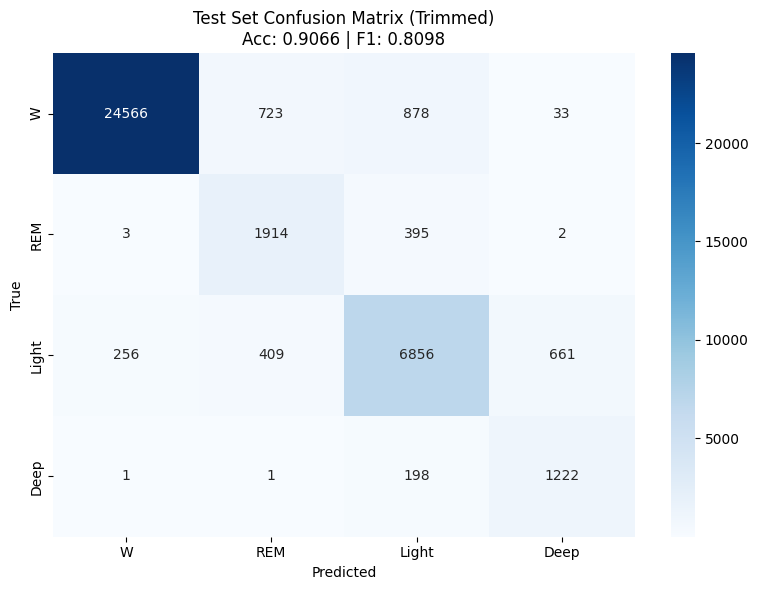

In [5]:
# 执行测试集评估
# 注意：需要先运行前面的单元格加载模型和定义类
log = True

predictor = SleepPredictorV1(
        model_path='./sleep-edf/data/model/model021101.pth',
        device='cuda',
        window_size=15
    )
predictor.load_model(SleepStageNetV8)

# 运行评估
eval_results = evaluate_test_set(predictor, test_folder)

Found 16 valid patients in test set

--- Processing SC4031 ---
 4-class Acc: 0.9592 | 4-class F1: 0.8532 | Acc: {'W': '0.9925', 'REM': '0.9378', 'Light': '0.8462', 'Deep': '0.9474'} | Samples: 2820
 5-class Acc: 0.9507 | 5-class F1: 0.7857 | Acc: {'W': '0.9925', 'N1': '0.4918', 'N2': '0.8412', 'N3': '0.9474', 'REM': '0.9378'} | Samples: 2820

--- Processing SC4032 ---
 4-class Acc: 0.9564 | 4-class F1: 0.9046 | Acc: {'W': '0.9775', 'REM': '0.9548', 'Light': '0.9169', 'Deep': '0.7786'} | Samples: 2732
 5-class Acc: 0.9495 | 5-class F1: 0.8181 | Acc: {'W': '0.9775', 'N1': '0.4444', 'N2': '0.9225', 'N3': '0.7786', 'REM': '0.9548'} | Samples: 2732

--- Processing SC4041 ---
 4-class Acc: 0.9385 | 4-class F1: 0.8713 | Acc: {'W': '0.9641', 'REM': '0.8929', 'Light': '0.9135', 'Deep': '0.7358'} | Samples: 2569
 5-class Acc: 0.9097 | 5-class F1: 0.8122 | Acc: {'W': '0.9641', 'N1': '0.7169', 'N2': '0.8468', 'N3': '0.7358', 'REM': '0.8929'} | Samples: 2569

--- Processing SC4111 ---
 4-class Acc:

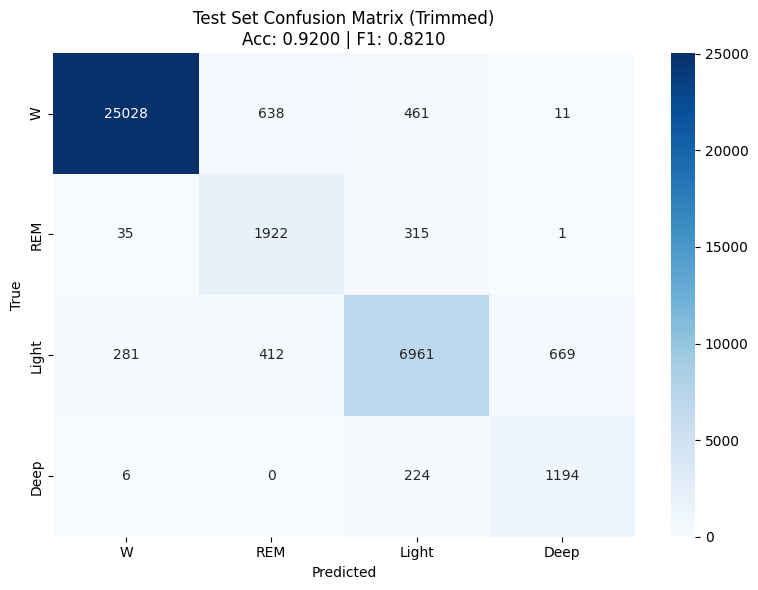

In [6]:
# 执行测试集评估
# 注意：需要先运行前面的单元格加载模型和定义类
log = True

predictor = SleepPredictorV1(
        model_path='./sleep-edf/data/model/model031401.pth',
        device='cuda',
        window_size=15
    )
predictor.load_model(SleepStageNetV8)

# 运行评估
eval_results = evaluate_test_set(predictor, test_folder)

1. 测试比较成功，可开始前后端标准化
2. 可试用Vue-假数据样板设计先？
3. 关于可以画两个图 其一：20小时的完整预测 其二：预测完成后截取其中的睡眠阶段进行展示
4. 前端应用页面企业化
